# Perbandingan Akhir: 6 Model Deep Learning untuk Klasifikasi Seizure (EEG)

Notebook ini menggabungkan hasil dari dua notebook sebelumnya:
- `Model_SMOTE.ipynb` → CNN, LSTM, CNN-LSTM (dilatih dengan SMOTE)
- `Model_TanpaSMOTE.ipynb` → CNN, LSTM, CNN-LSTM (dilatih tanpa SMOTE)

Total ada 6 model yang dibandingkan pada Data Testing yang identik, untuk menentukan 1 model terbaik yang akan diintegrasikan ke GUI Mobile/Website.


## 0. Import Library

In [14]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

import keras

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Keras version:", keras.__version__)


Keras version: 3.13.2


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Memuat Hasil Evaluasi 6 Model

Hasil evaluasi (Accuracy, Precision, Recall, F1-Score) setiap model sudah disimpan sebagai file JSON oleh masing-masing notebook sebelumnya, sehingga tidak perlu melatih ulang model di sini.


In [16]:
with open('artifacts/metrics_smote.json') as f:
    metrics_smote = json.load(f)

with open('artifacts/metrics_tanpasmote.json') as f:
    metrics_tanpasmote = json.load(f)

rows = []
for model_name, m in metrics_smote.items():
    rows.append({'Model': model_name, 'Penanganan Imbalance': 'SMOTE', **m})
for model_name, m in metrics_tanpasmote.items():
    rows.append({'Model': model_name, 'Penanganan Imbalance': 'Tanpa SMOTE', **m})

df_all = pd.DataFrame(rows)
df_all['Label'] = df_all['Model'] + ' + ' + df_all['Penanganan Imbalance']
df_all = df_all.rename(columns={'accuracy':'Accuracy','precision':'Precision','recall':'Recall','f1':'F1-Score'})
df_all = df_all[['Label','Model','Penanganan Imbalance','Accuracy','Precision','Recall','F1-Score']]
df_all


,Label,Model,Penanganan Imbalance,Accuracy,Precision,Recall,F1-Score
0,CNN + SMOTE,CNN,SMOTE,0.968696,0.870229,0.991304,0.926829
1,LSTM + SMOTE,LSTM,SMOTE,0.974783,0.897233,0.986957,0.939959
2,CNN+LSTM + SMOTE,CNN+LSTM,SMOTE,0.984348,0.930894,0.995652,0.962185
3,CNN + Tanpa SMOTE,CNN,Tanpa SMOTE,0.988696,0.957806,0.986957,0.972163
4,LSTM + Tanpa SMOTE,LSTM,Tanpa SMOTE,0.979130,0.959821,0.934783,0.947137
5,CNN+LSTM + Tanpa SMOTE,CNN+LSTM,Tanpa SMOTE,0.990435,0.962025,0.991304,0.976445


### 1.1 Tabel Komparasi Diurutkan Berdasarkan Accuracy

In [17]:
df_ranked = df_all.sort_values(['Accuracy','F1-Score'], ascending=False).reset_index(drop=True)
df_ranked.index = df_ranked.index + 1
df_ranked.index.name = 'Peringkat'
df_ranked_display = df_ranked.copy()
for col in ['Accuracy','Precision','Recall','F1-Score']:
    df_ranked_display[col] = df_ranked_display[col].round(4)
df_ranked_display


,Label,Model,Penanganan Imbalance,Accuracy,Precision,Recall,F1-Score
Peringkat,,,,,,,
1,CNN+LSTM + Tanpa SMOTE,CNN+LSTM,Tanpa SMOTE,0.9904,0.9620,0.9913,0.9764
2,CNN + Tanpa SMOTE,CNN,Tanpa SMOTE,0.9887,0.9578,0.9870,0.9722
3,CNN+LSTM + SMOTE,CNN+LSTM,SMOTE,0.9843,0.9309,0.9957,0.9622
4,LSTM + Tanpa SMOTE,LSTM,Tanpa SMOTE,0.9791,0.9598,0.9348,0.9471
5,LSTM + SMOTE,LSTM,SMOTE,0.9748,0.8972,0.9870,0.9400
6,CNN + SMOTE,CNN,SMOTE,0.9687,0.8702,0.9913,0.9268


## 2. Visualisasi Komparasi 6 Model


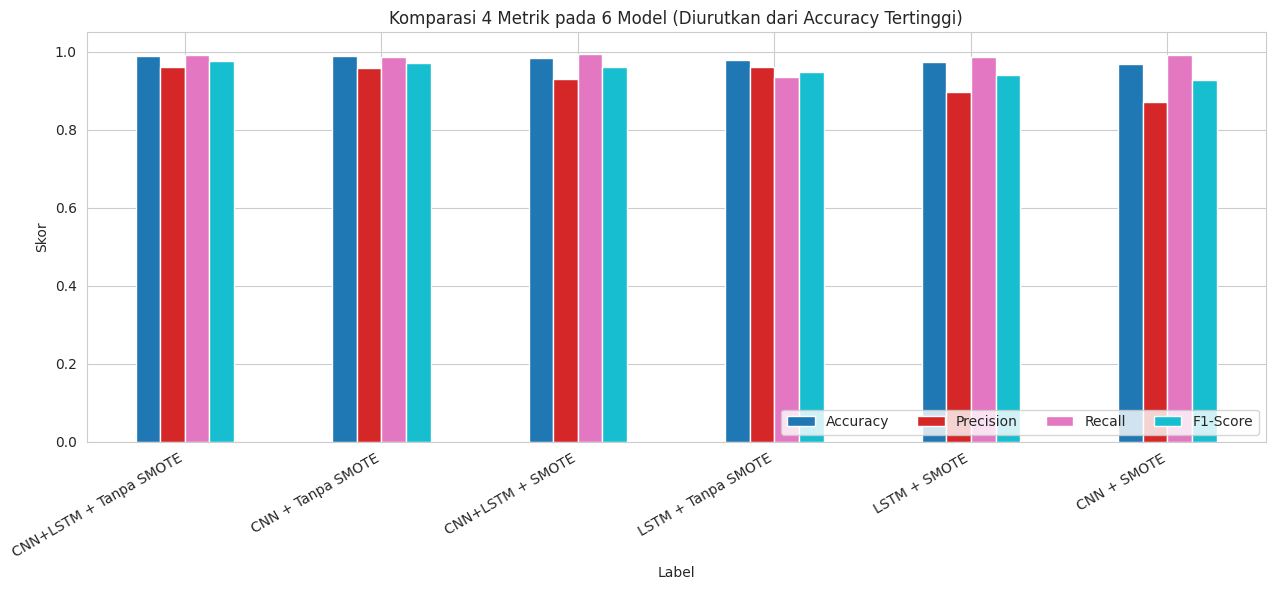

In [18]:
fig, ax = plt.subplots(figsize=(13,6))
plot_df = df_all.set_index('Label')[['Accuracy','Precision','Recall','F1-Score']]
plot_df = plot_df.loc[df_ranked.sort_values('Accuracy', ascending=False)['Label']]
plot_df.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Komparasi 4 Metrik pada 6 Model (Diurutkan dari Accuracy Tertinggi)')
ax.set_ylabel('Skor')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', ncol=4)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('artifacts/10_komparasi_6model_bar.png', dpi=120)
plt.show()


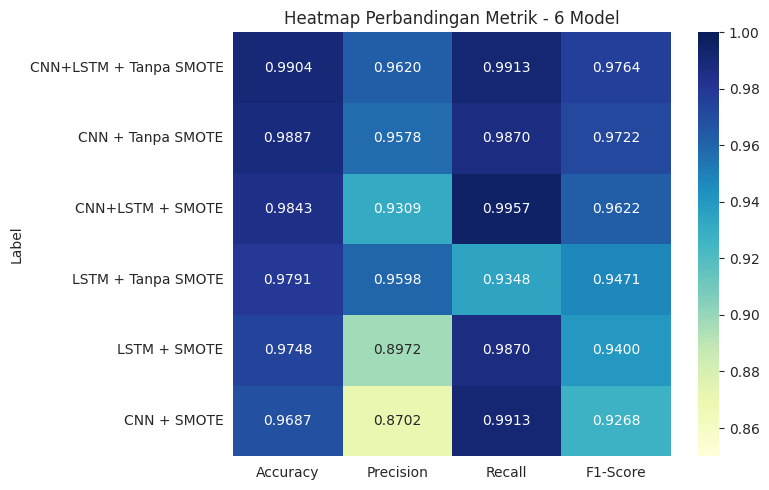

In [19]:
fig, ax = plt.subplots(figsize=(8,5))
heat_df = df_all.set_index('Label')[['Accuracy','Precision','Recall','F1-Score']]
heat_df = heat_df.loc[df_ranked.sort_values('Accuracy', ascending=False)['Label']]
sns.heatmap(heat_df, annot=True, fmt='.4f', cmap='YlGnBu', vmin=0.85, vmax=1.0, ax=ax)
ax.set_title('Heatmap Perbandingan Metrik - 6 Model')
plt.tight_layout()
plt.savefig('artifacts/11_heatmap_6model.png', dpi=120)
plt.show()


### 2.1 Fokus: Perbandingan Accuracy (SMOTE vs Tanpa SMOTE per Arsitektur)

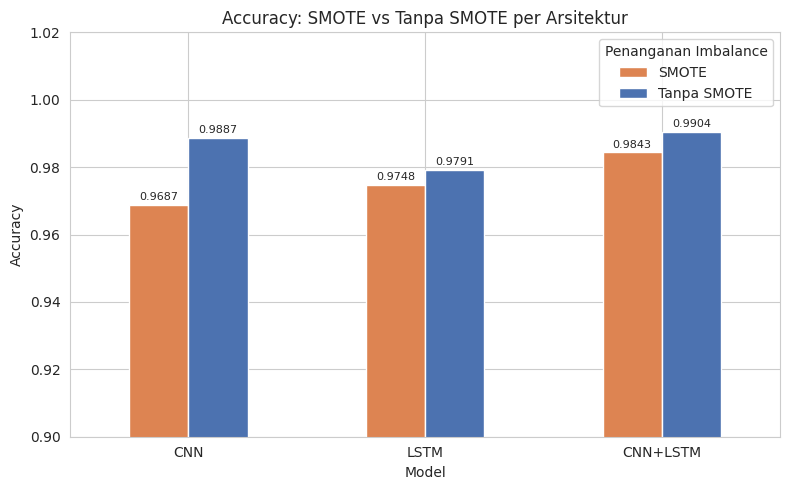

Rata-rata kenaikan accuracy karena SMOTE: -0.0101


In [20]:
fig, ax = plt.subplots(figsize=(8,5))
pivot_acc = df_all.pivot(index='Model', columns='Penanganan Imbalance', values='Accuracy')
pivot_acc = pivot_acc.loc[['CNN','LSTM','CNN+LSTM']]
pivot_acc.plot(kind='bar', ax=ax, color=['#DD8452','#4C72B0'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=2, fontsize=8)
ax.set_title('Accuracy: SMOTE vs Tanpa SMOTE per Arsitektur')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.9, 1.02)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('artifacts/12_accuracy_smote_vs_tanpasmote.png', dpi=120)
plt.show()

print("Rata-rata kenaikan accuracy karena SMOTE:",
      round((pivot_acc['SMOTE'] - pivot_acc['Tanpa SMOTE']).mean(), 4))


## 3. Confusion Matrix Gabungan (6 Model)

Untuk memastikan konsistensi, keenam model dimuat kembali dan diuji langsung pada Data Testing yang sama (`artifacts/data_splits.npz`) di sini, alih-alih hanya menempel gambar dari notebook sebelumnya.


In [21]:
data = np.load('artifacts/data_splits.npz')
X_test_scaled, y_test = data['X_test'], data['y_test']
X_test_final = X_test_scaled.reshape(-1, 89, 1)

print("Shape data testing:", X_test_final.shape)


Shape data testing: (1150, 89, 1)


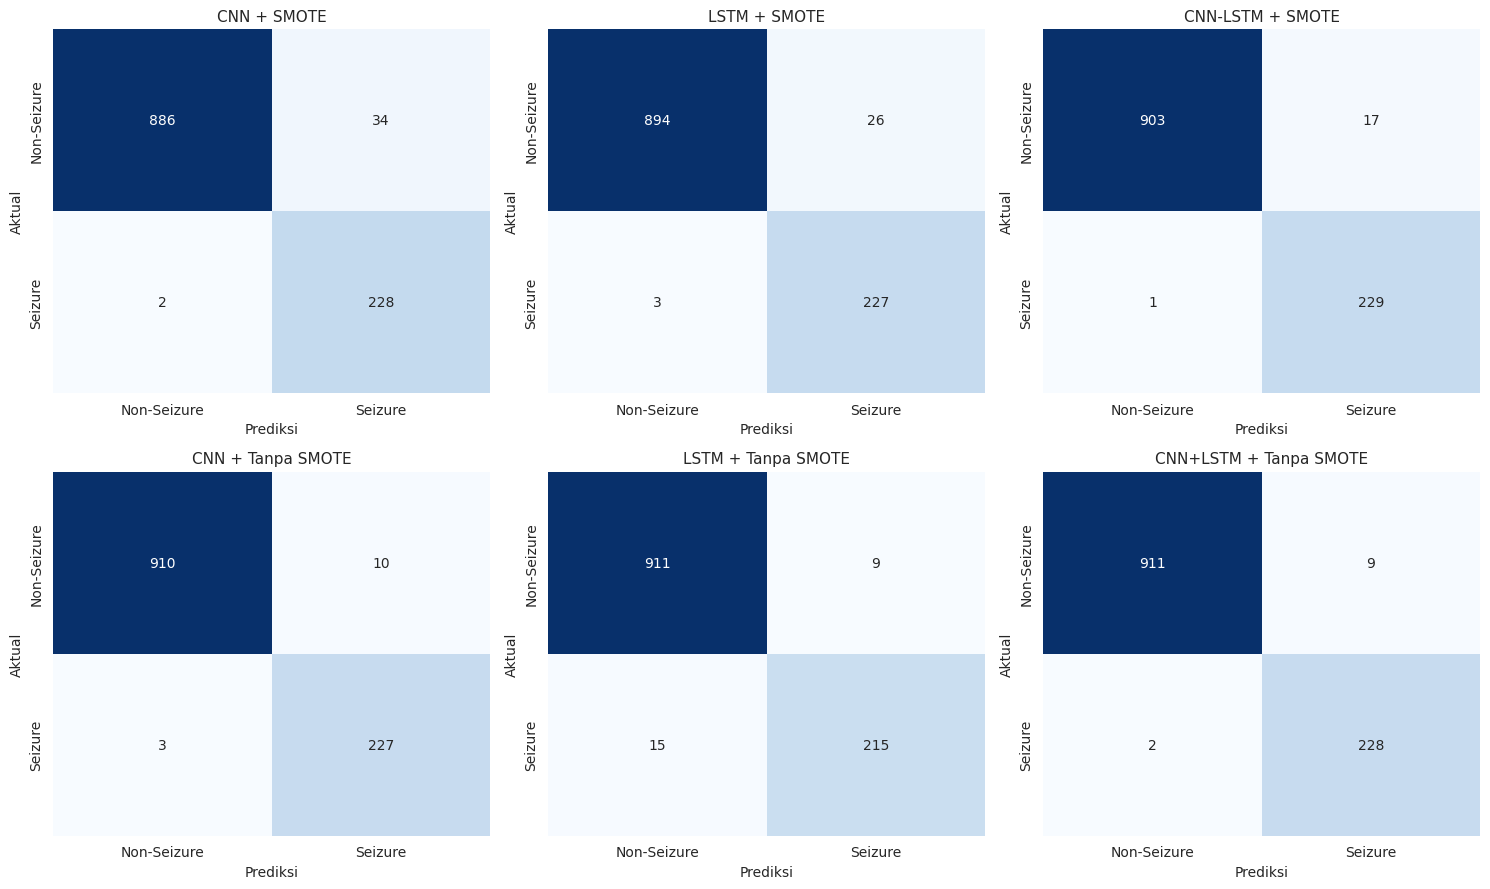

In [33]:
model_files = {
    'CNN + SMOTE': 'artifacts/model_CNN_smote.keras',
    'LSTM + SMOTE': 'artifacts/model_LSTM_smote.keras',
    'CNN-LSTM + SMOTE': 'artifacts/model_CNNLSTM_smote.keras',
    'CNN + Tanpa SMOTE': 'artifacts/model_CNN_tanpasmote.keras',
    'LSTM + Tanpa SMOTE': 'artifacts/model_LSTM_tanpasmote.keras',
    'CNN+LSTM + Tanpa SMOTE': 'artifacts/model_CNNLSTM_tanpasmote.keras',
}

fig, axes = plt.subplots(2, 3, figsize=(15,9))
axes = axes.ravel()

for ax, (label, path) in zip(axes, model_files.items()):
    model = keras.models.load_model(path)
    y_pred = (model.predict(X_test_final, verbose=0).ravel() >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non-Seizure','Seizure'],
                yticklabels=['Non-Seizure','Seizure'], ax=ax, cbar=False)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')

plt.tight_layout()
plt.savefig('artifacts/13_confusion_matrix_6model.png', dpi=120)
plt.show()


## 4. Analisis Trade-off Precision vs Recall

Pada kasus deteksi seizure, Recall (kemampuan mendeteksi kondisi seizure yang sebenarnya) sangat penting secara medis — melewatkan kasus seizure (false negative) jauh lebih berisiko dibanding "salah waspada" (false positive). Grafik berikut membantu melihat model mana yang menyeimbangkan keduanya paling baik.


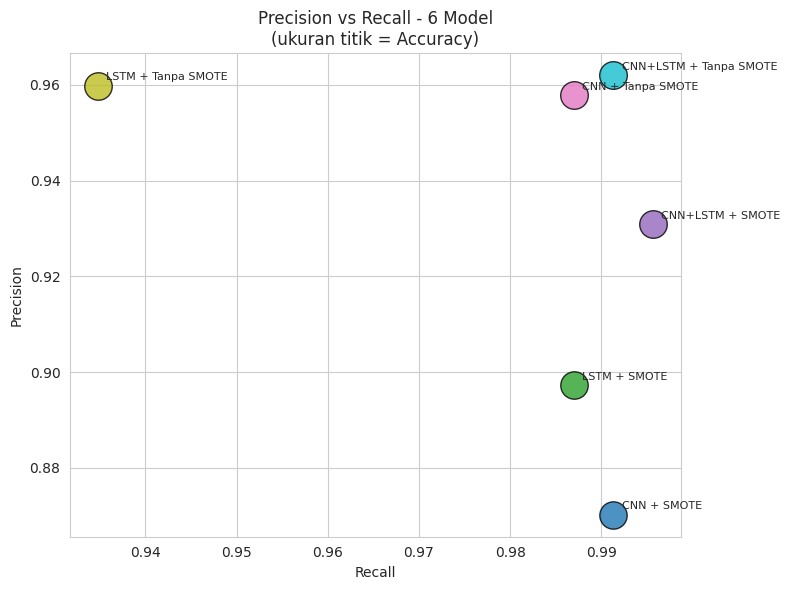

In [34]:
fig, ax = plt.subplots(figsize=(8,6))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_all)))
for (_, row), c in zip(df_all.iterrows(), colors):
    ax.scatter(row['Recall'], row['Precision'], s=row['Accuracy']*400, color=c, alpha=0.8, edgecolor='black')
    ax.annotate(row['Label'], (row['Recall'], row['Precision']),
                textcoords="offset points", xytext=(6,4), fontsize=8)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision vs Recall - 6 Model\n(ukuran titik = Accuracy)')
plt.tight_layout()
plt.savefig('artifacts/14_tradeoff_precision_recall.png', dpi=120)
plt.show()


## 5. Pemilihan Model Terbaik


In [35]:
top1 = df_ranked.iloc[0]
top2 = df_ranked.iloc[1]

print("=== PERINGKAT (berdasarkan Accuracy, tie-break F1-Score) ===")
for i, row in df_ranked.iterrows():
    print(f"{i}. {row['Label']:<28} Accuracy={row['Accuracy']:.4f}  Precision={row['Precision']:.4f}  "
          f"Recall={row['Recall']:.4f}  F1={row['F1-Score']:.4f}")

print(f"\n>>> MODEL TERBAIK: {top1['Label']}")
print(f"    Accuracy  : {top1['Accuracy']:.4f}")
print(f"    Precision : {top1['Precision']:.4f}")
print(f"    Recall    : {top1['Recall']:.4f}")
print(f"    F1-Score  : {top1['F1-Score']:.4f}")

if abs(top1['Accuracy'] - top2['Accuracy']) < 1e-6:
    print(f"\nCatatan: Accuracy model peringkat 1 ({top1['Label']}) dan peringkat 2 ({top2['Label']}) "
          f"identik ({top1['Accuracy']:.4f}). Keputusan pemenang ditentukan dari F1-Score "
          f"({top1['F1-Score']:.4f} vs {top2['F1-Score']:.4f}).")


=== PERINGKAT (berdasarkan Accuracy, tie-break F1-Score) ===
1. CNN+LSTM + Tanpa SMOTE       Accuracy=0.9904  Precision=0.9620  Recall=0.9913  F1=0.9764
2. CNN + Tanpa SMOTE            Accuracy=0.9887  Precision=0.9578  Recall=0.9870  F1=0.9722
3. CNN+LSTM + SMOTE             Accuracy=0.9843  Precision=0.9309  Recall=0.9957  F1=0.9622
4. LSTM + Tanpa SMOTE           Accuracy=0.9791  Precision=0.9598  Recall=0.9348  F1=0.9471
5. LSTM + SMOTE                 Accuracy=0.9748  Precision=0.8972  Recall=0.9870  F1=0.9400
6. CNN + SMOTE                  Accuracy=0.9687  Precision=0.8702  Recall=0.9913  F1=0.9268

>>> MODEL TERBAIK: CNN+LSTM + Tanpa SMOTE
    Accuracy  : 0.9904
    Precision : 0.9620
    Recall    : 0.9913
    F1-Score  : 0.9764


## 6. Integrasi GUI

Menyalin model terbaik dan scaler ke dalam satu paket siap pakai (`artifacts/best_model/`) agar mudah dimuat oleh aplikasi GUI Mobile/Website.


In [36]:
import shutil, os

best_label = top1['Label']
best_model_key = best_label.replace(' + ', '_').replace('-', '').replace(' ', '')
best_source_path = model_files[best_label]

os.makedirs('artifacts/best_model', exist_ok=True)
shutil.copy(best_source_path, 'artifacts/best_model/best_model.keras')
shutil.copy('artifacts/scaler.pkl', 'artifacts/best_model/scaler.pkl')

with open('artifacts/best_model/model_info.json', 'w') as f:
    json.dump({
        'nama_model': best_label,
        'accuracy': float(top1['Accuracy']),
        'precision': float(top1['Precision']),
        'recall': float(top1['Recall']),
        'f1_score': float(top1['F1-Score']),
        'jumlah_fitur_input': 89,
        'preprocessing': 'downsampling 178->89 (average pooling 2 titik), StandardScaler, reshape ke (89,1)',
        'label_output': {'0': 'Non-Seizure', '1': 'Seizure'}
    }, f, indent=2)

df_ranked.to_csv('artifacts/tabel_komparasi_6model.csv')

print(f"Model terbaik ({best_label}) & scaler disalin ke artifacts/best_model/")
print("Tabel komparasi lengkap disimpan ke artifacts/tabel_komparasi_6model.csv")


Model terbaik (CNN+LSTM + Tanpa SMOTE) & scaler disalin ke artifacts/best_model/
Tabel komparasi lengkap disimpan ke artifacts/tabel_komparasi_6model.csv
